# California Housing Regression

# PROBLEM UNDERSTANDING:

The goal of this project is to predict the median house value in california districts based on various housing related features
This is a supervised machine learning problem because:
- We have input features (X)
- We have a target variable (y)

Type of problem: Regression

Target Variable:
- MedHouseVal (Median House Value)

Input Features:
- MedInc (Median Income)
- HouseAge
- AveRooms
- AveBedrms
- Population
- AveOccup
- Latitude
- Longitude

Objective:
Build a regression model (Linear Regression / Decision Tree) 
to predict house prices and evaluate its performance using MAE, RMSE, and R² score. 

# Import Libraries

In [26]:
# TODO: Import pandas, numpy, matplotlib.pyplot, seaborn
# TODO: Import train_test_split, StandardScaler
# TODO: Import LinearRegression, metrics (mean_absolute_error, mean_squared_error, r2_score)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your scikit-learn imports below:
from sklearn.datasets import _california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.tree import DecisionTreeRegressor



# Load Dataset

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Data Understanding

In [11]:
print("shape")
print(df.shape)

print("info ")
print(df.info())

print("describe ")
print(df.describe())



shape
(20640, 9)
info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
describe 
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000   

# Data Cleaning

In [16]:
# Check missing values
print("Does this Dataset contain any null values")
print(df.isnull().sum())

# Check duplicates
print("Does this Dataset contain any duplicate values")
print(df.duplicated().sum())

# This Data set does not conatin any null values and duplicates


Does this Dataset contain any null values
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Does this Dataset contain any duplicate values
0


# EDA & VISUALISATION

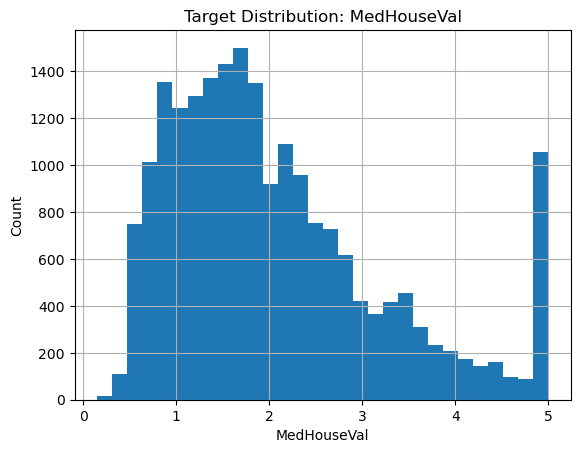

In [18]:
df["MedHouseVal"].hist(bins=30)
plt.title("Target Distribution: MedHouseVal")
plt.xlabel("MedHouseVal")
plt.ylabel("Count")
plt.show()

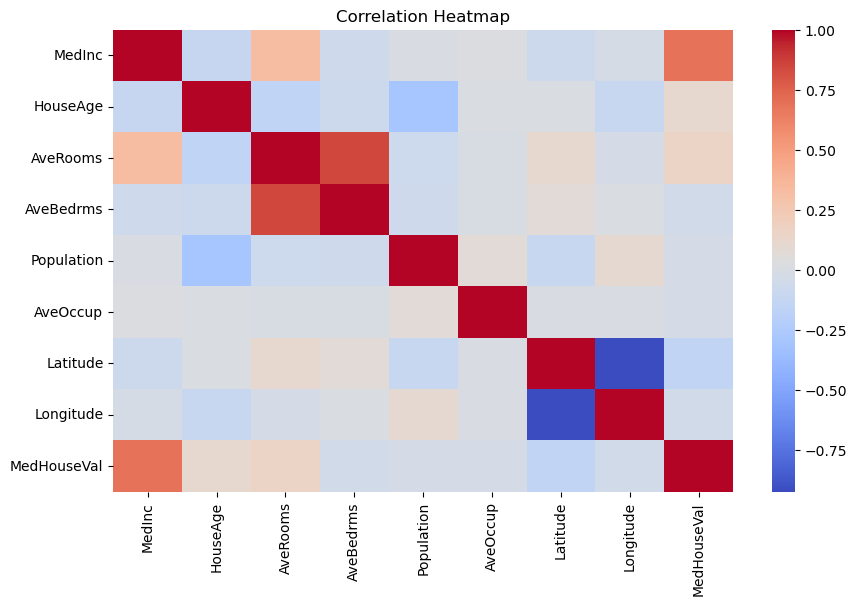

In [19]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

In [21]:
# 1. Separate features (X) and target (y)
X = df.drop("MedHouseVal", axis=1) # It gets all features except MedHouseVal - Its a column , so axis=1
y = df["MedHouseVal"]

# TODO: 2. Split the data into Training and Testing sets (e.g., 80% train, 20% test)
# Hint: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


# Scaling

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Models

In [27]:
# Linear Regression
lin_req = LinearRegression()
lin_req.fit(X_train_scaled,y_train)
y_pred_lr = lin_req.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


# Model Evaluation

In [29]:
def eval_regression(y_true, y_pred, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

eval_regression(y_test, y_pred_lr, "Linear Regression")
eval_regression(y_test, y_pred_dt, "Decision Tree")

Linear Regression -> MAE: 0.5332 | RMSE: 0.7456 | R2: 0.5758
Decision Tree -> MAE: 0.4332 | RMSE: 0.6446 | R2: 0.6829


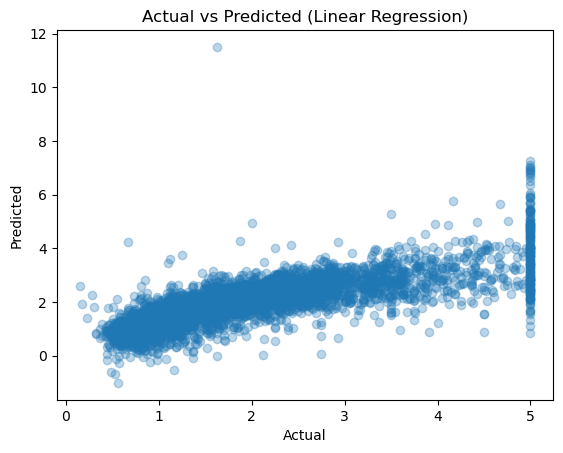

In [30]:
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()